**Importing Libraries and Dataset**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
revenue_df = pd.read_csv('customer_shopping_behavior.csv')
revenue_df.head(5)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [3]:
revenue_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null   str    
 15

In [4]:
revenue_df.describe()      #use include = 'all' for non categorial data

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [5]:
(revenue_df == ' ').sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [6]:
# revenue_df.isna().sum()
revenue_df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

We are filling the NA value within review section with median values of the reviews. However, each product needs their median review and we cannot give the same generated value to each product, we will group it as per it's product category.

In [7]:
revenue_df['Review Rating'] = revenue_df.groupby('Category')['Review Rating'].transform(lambda x: x.fillna(x.median()))

Converting the column names to lowercase and replacing the space with underscore for easy access 

In [8]:
revenue_df.columns = revenue_df.columns.str.replace(' ', '_')
revenue_df.columns = revenue_df.columns.str.lower()

# update purchase_amt_usd to correct name
revenue_df = revenue_df.rename(columns={'purchase_amount_(usd)' : 'purchase_amount'})

In [9]:
print(revenue_df['review_rating'].map(type).value_counts())

review_rating
<class 'float'>    3900
Name: count, dtype: int64


In [10]:
revenue_df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='str')

In [11]:
revenue_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             3900 non-null   int64  
 1   age                     3900 non-null   int64  
 2   gender                  3900 non-null   str    
 3   item_purchased          3900 non-null   str    
 4   category                3900 non-null   str    
 5   purchase_amount         3900 non-null   int64  
 6   location                3900 non-null   str    
 7   size                    3900 non-null   str    
 8   color                   3900 non-null   str    
 9   season                  3900 non-null   str    
 10  review_rating           3900 non-null   float64
 11  subscription_status     3900 non-null   str    
 12  shipping_type           3900 non-null   str    
 13  discount_applied        3900 non-null   str    
 14  promo_code_used         3900 non-null   str    
 15

In [12]:
# Creating age group
age_labels = ['Young Adult', 'Adult', 'Middle Age', 'Senior']
revenue_df['age_group'] = pd.qcut(revenue_df['age'], q = 4, labels=age_labels)
revenue_df[['age', 'age_group']].head(5)

,age,age_group
0,55,Middle Age
1,19,Young Adult
2,50,Middle Age
3,21,Young Adult
4,45,Middle Age


In [13]:
# purcharse frequency_days
# revenue_df['frequency_of_purchases'].unique()

days_mapping = {
    'Fortnightly' : 14,
    'Weekly' : 7,
    'Annually' : 365,
    'Quarterly' : 90,
    'Bi-Weekly' : 14,
    'Monthly' : 30,
    'Every 3 Months' : 90
}

revenue_df['purchase_frequency_days'] = revenue_df['frequency_of_purchases'].map(days_mapping)
revenue_df[['frequency_of_purchases', 'purchase_frequency_days']]


,frequency_of_purchases,purchase_frequency_days
0,Fortnightly,14
1,Fortnightly,14
2,Weekly,7
3,Weekly,7
4,Annually,365
...,...,...
3895,Weekly,7
3896,Bi-Weekly,14
3897,Quarterly,90
3898,Weekly,7


In [14]:
(revenue_df['discount_applied'] == revenue_df['promo_code_used']).all()

True

In [15]:
revenue_df = revenue_df.drop('promo_code_used', axis = 1)

In [16]:
revenue_df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days'],
      dtype='str')

In [17]:
print(revenue_df.dtypes)

customer_id                   int64
age                           int64
gender                          str
item_purchased                  str
category                        str
purchase_amount               int64
location                        str
size                            str
color                           str
season                          str
review_rating               float64
subscription_status             str
shipping_type                   str
discount_applied                str
previous_purchases            int64
payment_method                  str
frequency_of_purchases          str
age_group                  category
purchase_frequency_days       int64
dtype: object


In [18]:
# revenue_df.to_csv("Updated_Revenue_Dataset.csv", index=False)

**Data Plotting for understanding the data**

<Axes: xlabel='count', ylabel='item_purchased'>

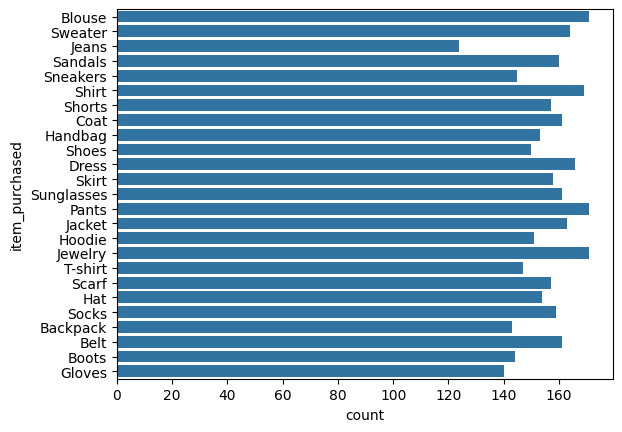

In [19]:
sns.countplot(revenue_df['item_purchased'])

<Axes: xlabel='count', ylabel='age_group'>

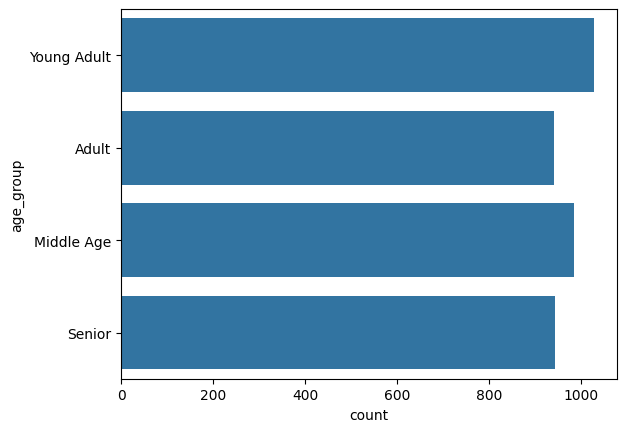

In [20]:
sns.countplot(revenue_df['age_group'])

<Axes: xlabel='count', ylabel='season'>

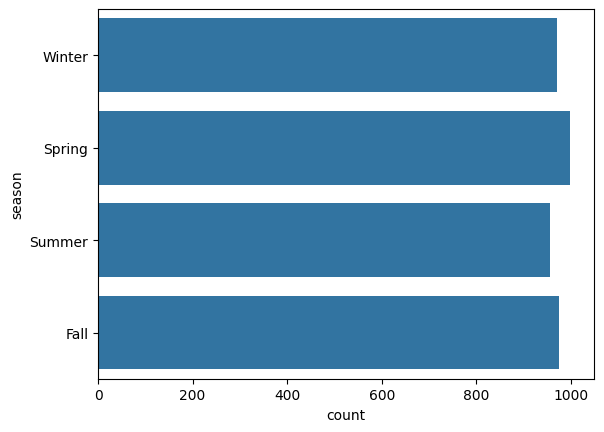

In [21]:
sns.countplot(revenue_df['season'])

<Axes: xlabel='age_group', ylabel='previous_purchases'>

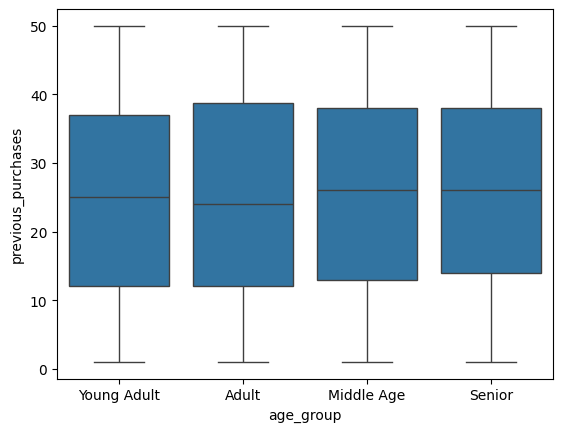

In [22]:
sns.boxplot(x = revenue_df['age_group'], y= revenue_df['previous_purchases'])

<Axes: xlabel='review_rating', ylabel='frequency_of_purchases'>

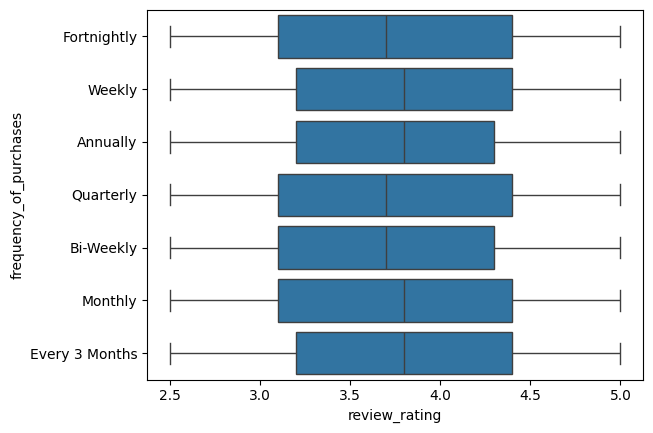

In [32]:
sns.boxplot(x = revenue_df['review_rating'], y= revenue_df['frequency_of_purchases'])

<Axes: xlabel='age_group', ylabel='count'>

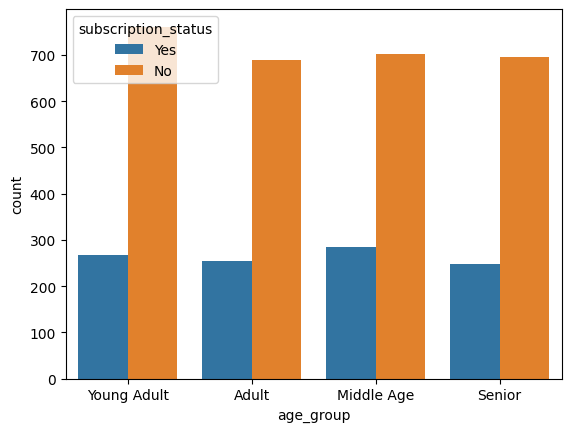

In [ ]:
sns.countplot(x=revenue_df['age_group'], hue=revenue_df['subscription_status'])

<Axes: xlabel='purchase_amount', ylabel='Count'>

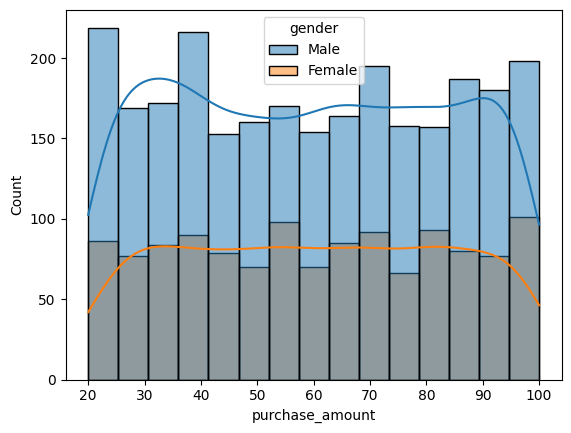

In [ ]:
sns.histplot(x=revenue_df['purchase_amount'], hue=revenue_df['gender'], kde=True)

<Axes: xlabel='previous_purchases', ylabel='shipping_type'>

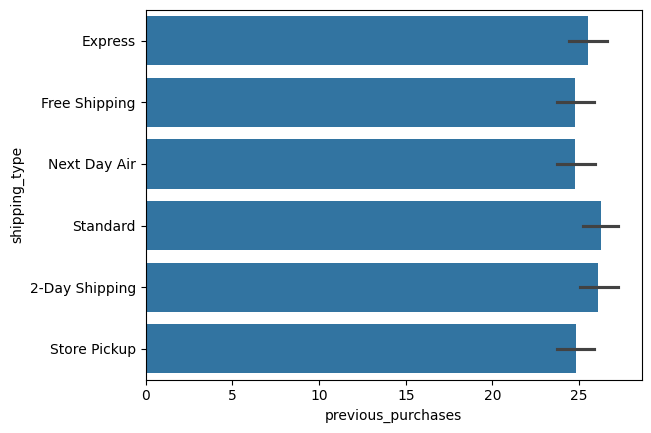

In [31]:
sns.barplot(x=revenue_df['previous_purchases'], y=revenue_df['shipping_type'])

<Axes: >

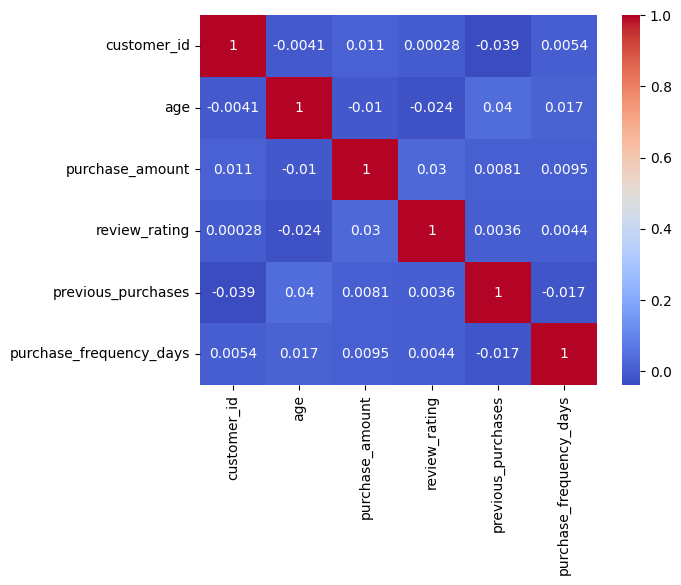

In [24]:
sns.heatmap(revenue_df.corr(numeric_only=True), annot=True, cmap='coolwarm')

<Axes: xlabel='category', ylabel='age_group'>

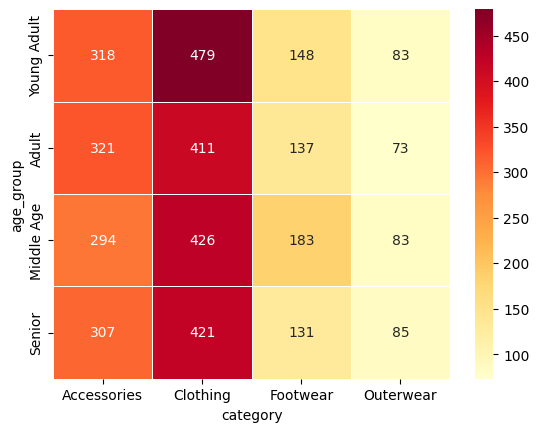

In [ ]:
ct = pd.crosstab(revenue_df['age_group'], revenue_df['category'])

sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)

In [40]:
from dotenv import load_dotenv
import os
from sqlalchemy import create_engine

load_dotenv()

PASSWORD = os.getenv('PASSWORD')
if not PASSWORD:
    raise ValueError('PASSWORD not set in the environment')

username = 'postgres'
password = PASSWORD
host = "127.0.0.1"
port = "5432"
database = "revenue_db"

engine = create_engine(
    f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}"
)

print('Connection successful')

table_name = 'revenue_data'
try:
    revenue_df.to_sql(
        name=table_name,
        con=engine,
        if_exists="replace",
        index=False
    )
    print(f"Data uploaded successfully into table {table_name} in database {database}.")

except Exception as e:
    print(type(e))
    print(e)


Connection successful
Data uploaded successfully into table revenue_data in database revenue_db.
